# ENSO Validation Figures

This notebook contains some of the main proposed ENSO validation figures for the ENSO-NAO Teleconnection Paper, including:

1. Mean and Standard Deviation of Tropical Pacific SSTs

2. Monthly Standard Deviation of Niño3.4 Index

3. Power Spectra of Niño3.4 Index


Mean and Standard Deviation Files were calculated using cdo in `ensonao_mean_stdev.sh`, and precalculate files are available at this google drive link: `https://drive.google.com/drive/folders/12Dz-GS9M-YCMg6dKxJcFVX5AAyM_3D58?usp=sharing`

Please change the paths to match the location of the directories on your machine.

Necessary modules are indicated in the `baseclim.yml` file of the repository: `https://github.com/glennliu265/enso_nao_teleconnections/blob/main/scripts/baseclim.yml`

Write to me (Glenn Liu, gliu8@hawaii.edu) if you have any questions or run into issues while using this notebook.

In [1]:
import sys
import time
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import xarray as xr
import sys
import tqdm
import glob 
import scipy as sp
import cartopy.crs as ccrs
import matplotlib as mpl
from tqdm.notebook import tqdm
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import calendar as cal

In [22]:
# Helper Functions

def init_tp_map(nrow=1,ncol=1,figsize=(12.5,4.5),ax=None,latmax=20,lonbounds=[120,290],):
    lonW,lonE = lonbounds
    bbplot  = [lonW, lonE, -latmax, latmax]
    fix_lon = np.hstack([np.arange(lonW,190,10),np.arange(-180,(lonE-360)+10,10)])
    proj    = ccrs.PlateCarree(central_longitude=180)
    
    if ax is None:
        fig,axs = plt.subplots(nrow,ncol,figsize=figsize,subplot_kw={'projection':proj})
        newfig = True
    else:
        newfig = False
    if nrow != 1 or ncol != 1:
        for ax in axs.flatten():
            ax.set_extent(bbplot)
            ax     = add_coast_grid(ax,bbox=bbplot,fill_color='k',
                                        proj=ccrs.PlateCarree(),fix_lon=fix_lon,ignore_error=True)
        ax = axs
    else:
        ax = axs
        ax.set_extent(bbplot)
        ax     = add_coast_grid(ax,bbox=bbplot,fill_color='k',
                                    proj=ccrs.PlateCarree(),fix_lon=fix_lon,ignore_error=True)
    
    if newfig:
        return fig,ax
    return ax

def add_coast_grid(ax,bbox=[-180,180,-90,90],proj=None,blabels=[1,0,0,1],ignore_error=False,
                   fill_color=None,line_color='k',grid_color='gray',c_zorder=1,
                   fix_lon=False,fix_lat=False,fontsize=12):
    """
    Add Coastlines, grid, and set extent for geoaxes
    
    Parameters
    ----------
    ax : matplotlib geoaxes
        Axes to plot on 
    bbox : [LonW,LonE,LatS,LatN], optional
        Bounding box for plotting. The default is [-180,180,-90,90].
    proj : cartopy.crs, optional
        Projection. The default is None.
    blabels : ARRAY of BOOL [Left, Right, Upper, Lower] or dict
        Lat/Lon Labels. Default is [1,0,0,1]
    ignore_error : BOOL
        Set to True to ignore error associated with gridlabeling
    fill_color : matplotlib color string
        Add continents with a given fill
    c_zorder : layering order of the continents
    
    Returns
    -------
    ax : matplotlib geoaxes
        Axes with setup
    """
    
    if type(blabels) == dict: # Convert dict to array
        blnew = [0,0,0,0]
        if blabels['left'] == 1:
            blnew[0] = 1
        if blabels['right'] == 1:
            blnew[1] = 1
        if blabels['upper'] == 1:
            blnew[2] = 1
        if blabels['lower'] == 1:
            blnew[3] = 1
        blabels=blnew
    
    if proj is None:
        proj = ccrs.PlateCarree()
        
    if fill_color is not None: # Shade the land
        ax.add_feature(cfeature.LAND,facecolor=fill_color,zorder=c_zorder)
    #ax.add_feature(cfeature.COASTLINE,color=line_color,lw=0.75,zorder=0)
    ax.coastlines(color=line_color,lw=0.75)
    ax.set_extent(bbox,proj)
    
    gl = ax.gridlines(crs=proj, draw_labels=True,
                  linewidth=0.75, color=grid_color, alpha=0.5, linestyle="dotted",
                  )
    
    # Remove the degree symbol
    if ignore_error:
        #print("Removing Degree Symbol")
        gl.xformatter = LongitudeFormatter(zero_direction_label=False,degree_symbol='')
        gl.yformatter = LatitudeFormatter(degree_symbol='')
        #gl.yformatter = LatitudeFormatter(degree_symbol='')
        gl.rotate_labels = False
    
    if fix_lon is not False:
        gl.xlocator = mticker.FixedLocator(fix_lon)
    if fix_lat is not False:
        gl.ylocator = mticker.FixedLocator(fix_lat)
    
    gl.left_labels      = blabels[0]
    gl.right_labels     = blabels[1]
    gl.top_labels       = blabels[2]
    gl.bottom_labels    = blabels[3]
    
    # Set Fontsize
    gl.xlabel_style = {'size':fontsize}
    gl.ylabel_style = {'size':fontsize}
    return ax

# Functions copied from Sen Zhao's XRO code for spectral analysis
# https://github.com/senclimate/XRO/blob/main/XRO/stats.py
# Modification was made to remove lag1_r from xr.apply_ufunc

def pmtm(ds_x, dim='time', dt=1/12., nw=4, cl=0.95, nfft=None, scale_by_freq=True, lag1_r=None,
         return_dataset=False):
    """
    Thomson’s multitaper power spectral density (PSD) estimate, 
    PSD significance level estimate, Confidence Intervals

    PSD estimate modified from Peter Huybers's matlab code, pmtmPH.m
    PSD significance level estimate modified from NCAR/NCL specx_ci 

    Parameters
    ----------
    x : numpy array
        Time series to analyze
    dt : float
        Sampling interval, default is 1.
    nw : float
        The time bandwidth product, available 
    cl : float
        Confidence interval to calculate and display
    nfft: int
        Default 
    lag1_r: float
        significance test for AR(1) lag1_r value
    return_dataset: True or False
        return xarray dataset

    Returns
    -------
    x_P : xarray DataArray
        PSD estimate via the multi-taper method.
    x_P_sig : xarray DataArray
        PSD significance level estimate.
    x_ci : xarray DataArray
        Confidence intervals.
    """
    P_ds, s_ds, Psig_ds, ci_ds = xr.apply_ufunc(_pmtm, ds_x, input_core_dims=[[dim]],
                             output_core_dims=[['freq'], ['freq'], ['freq'], ['freq', 'bound', ]],
                             kwargs={'dt': dt, 'nw': nw, 'cl': cl,
                                     'nfft': nfft, 'scale_by_freq': scale_by_freq,},
                             vectorize=True)
    if len(s_ds.dims)==1:
        P_ds = P_ds.assign_coords({'freq': s_ds})
        Psig_ds = Psig_ds.assign_coords({'freq': s_ds})
        ci_ds = ci_ds.assign_coords({'freq': s_ds})
    else:
        mem_dim = list(s_ds.dims)[0]
        P_ds = P_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})
        Psig_ds = Psig_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})
        ci_ds = ci_ds.assign_coords({'freq': s_ds.isel({mem_dim: 0}).values})

    if return_dataset:
        out_ds = xr.Dataset({'P': P_ds, 'Psig': Psig_ds, 'Pci': ci_ds})
        out_ds.attrs['dt'] = dt
        out_ds.attrs['nw'] = nw
        out_ds.attrs['cl'] = cl
        out_ds.attrs['scale_by_freq'] = scale_by_freq
        return out_ds
    else:
        return P_ds, Psig_ds, ci_ds

def _pmtm(x, dt=1, nw=4, cl=0.95, nfft=None, scale_by_freq=True):
    '''
        numpy of pmtm
    '''

    from scipy.signal import windows
    from scipy.stats import chi2

    if nfft is None:
        nfft = np.shape(x)[0]

    nx = np.shape(x)[0]
    k = min(np.round(2.*nw), nx)
    k = int(max(k-1, 1))
    s = np.arange(0, 1/dt, 1/(nfft*dt))

    # Compute the discrete prolate spheroidal sequences
    [E, V] = windows.dpss(nx, nw, k, return_ratios=True)
    E = E.T

    # Compute the windowed DFTs.
    Pk = np.abs(np.fft.fft(E*x[:, np.newaxis], nfft, axis=0))**2

    # Iteration to determine adaptive weights
    if k > 1:
        sig2 = np.dot(x[np.newaxis, :], x[:, np.newaxis])[0][0]/nx # power
        # initial spectrum estimate
        P = ((Pk[:, 0] + Pk[:, 1])/2)[:, np.newaxis]
        Ptemp = np.zeros((nfft, 1))
        P1 = np.zeros((nfft, 1))
        tol = .0005*sig2/nfft
        a = sig2*(1-V)

        while (np.sum(np.abs(P - P1)/nfft) > tol):
            b = np.repeat(P, k, axis=-1)/(P*V[np.newaxis, :] + np.ones((nfft, 1))*a[np.newaxis, :])
            wk = (b**2) * (np.ones((nfft, 1))*V[np.newaxis, :])
            P1 = (np.sum(wk*Pk, axis=-1)/np.sum(wk, axis=-1))[:, np.newaxis]

            Ptemp = np.empty_like(P1)
            Ptemp[:] = P1
            P1 = np.empty_like(P)
            P1[:] = P
            P = np.empty_like(Ptemp)
            P[:] = Ptemp

        # Determine equivalent degrees of freedom, see Percival and Walden 1993.
        v = ((2*np.sum((b**2)*(np.ones((nfft, 1))*V[np.newaxis, :]), axis=-1)**2) /
             np.sum((b**4)*(np.ones((nfft, 1))*V[np.newaxis, :]**2), axis=-1))

    else:
        P = np.empty_like(Pk)
        P[:] = Pk
        v = 2*np.ones((nfft, 1))

    select = (np.arange(0, (nfft + 1)/2.)).astype('int')
    P = P[select].flatten()
    s = s[select].flatten()
    v = v[select].flatten()

    # Whether the resulting density values should be scaled by the scaling frequency, which gives density in units of 1/day, 1/year, or 1/Hz.
    # This allows for integration over the returned frequency values
    if scale_by_freq:
        P *= dt
    
    # Chi-squared 95% confidence interval
    # approximation from Chamber's et al 1983; see Percival and Walden p.256, 1993
    ci = np.empty((np.shape(v)[0], 2))
    ci[:, 0] = 1./(1-2/(9*v) - 1.96*np.sqrt(2/(9*v)))**3
    ci[:, 1] = 1./(1-2/(9*v) + 1.96*np.sqrt(2/(9*v)))**3
    
    # red noise significance levels
    # PSD significance level estimate modified from NCAR/NCL specx_ci 
    alpha = np.corrcoef(x[:-1], x[1:])[0, 1]
    dof = v
    P_red = (1 - alpha**2) / (1 + alpha**2 - 2 * alpha * np.cos(2 * np.pi * s * dt))
    # rescale
    scale = np.sum(P)/np.sum(P_red)
    quantile = chi2.ppf(cl, dof)
    P_sig = P_red * scale * quantile / dof
 
    x_s = xr.DataArray(s, dims=['freq'], coords={'freq': s})
    x_P = xr.DataArray(P, dims=['freq'], coords={'freq': s})
    x_P_sig = xr.DataArray(P_sig, dims=['freq'], coords={'freq': s})
    x_ci = xr.DataArray(ci, dims=['freq', 'bound'], coords={'freq': s, 'bound': [0, 1]})
    return x_P, x_s, x_P_sig, x_ci



def standardize_names(ds):
    
    # Time Names
    ds = swap_rename(ds,'valid_time','time')
    ds = swap_rename(ds,'time_counter','time') # ORAS5
    ds = swap_rename(ds,"TIME_COUNTER",'time')
    
    # Longitude Names
    ds = swap_rename(ds,"longitude","lon")
    ds = swap_rename(ds,"LON","lon")
    ds = swap_rename(ds,"nav_lon","lon") # ORAS5
    
    # Latitude Names
    ds = swap_rename(ds,"latitude","lat")
    ds = swap_rename(ds,"LAT","lat")
    ds = swap_rename(ds,"LAT232_409","lat")
    ds = swap_rename(ds,"nav_lat","lat") # ORAS5
    
    # Other preprocessing
    # drop LON_bnds, TIME_COUNTER_bnds
    dropvars = ["LON_bnds","TIME_COUNTER_bnds"]
    
    for dropvar in dropvars:
        if dropvar in ds:
            ds = ds.drop_vars(dropvar)
    return ds

def swap_rename(ds,chkvar,newvar):
    if chkvar in list(ds.coords):
        print("Renaming [%s] to [%s]" % (chkvar,newvar))
        ds = ds.rename({chkvar:newvar})
    return ds

def add_ylabel(label,ax=None,x=-0.10,y=0.5,fontsize=12,rotation='vertical'):
    if ax is None:
        ax = plt.gca()
    txt = ax.text(x, y, label, va='bottom', ha='center',rotation=rotation,
            rotation_mode='anchor',transform=ax.transAxes,fontsize=fontsize)
    return txt

def hcbar(mpl_obj,ax=None,fig=None,fraction=0.035,pad=.01,fontsize=12,rotation=0):
    """
    Make quick horizontal colorbar. Arguments are same as ax.colorbar()
    
    """
    if ax is None:
        ax = plt.gca()
    if fig is None:
        fig = plt.gcf()
    cb = plt.colorbar(mpl_obj,ax=ax,fraction=fraction,
                      pad=pad,orientation='horizontal',)
    cb.ax.tick_params(labelsize=fontsize,rotation=rotation)
    return cb

# Mean State and Standard Deviation

Currently written for 5 experiments during their control or historical states, whichever is available.:

1. AWI-CM3 TCo95
2. AWI-CM3 TCo319
3. AWI-CM3 TCo1279
4. EERIE IFS FESOM (WIP)
5. Observations, ERA5 Reanalyses

Note that we can swap out the reanalysis once we decide on the best product to use for observations.
We can also change the number of experiments but figures will need to be adjusted.

### Load the Data

In [12]:
%%time

expnames  = ["TCo95-hi1950d",
             "TCo319-DART-ctl1950d-gibbs-charn",
             "TCo1279-DART-1950",
             "EERIE_IFS_FESOM",
             "ERA5_1979_2024"
            ]

expcolors = [
        "cornflowerblue",
        "royalblue",
        "midnightblue",
        "goldenrod",
        "gray"
        ]

datpath     = "/home/niu4/gliu8/projects/enso_nao/mean_variables/" # (!!) Replace with your own path

figpath     = "/home/niu4/gliu8/figures/bydate/2026-07-28/"        # (!!) Replace with your own path


# Load Data
nexps       = len(expnames)
mean_byexp  = []
std_byexp   = []
for ex in tqdm(range(nexps)):

    try:
        expname = expnames[ex]
        ncname  = "%s%s_sst_mean.nc" % (datpath,expname)
        dsmean  = xr.open_dataset(ncname).sst.load()
        dsmean  = standardize_names(dsmean)
        mean_byexp.append(dsmean)
    
        ncname  = "%s%s_sst_std.nc" % (datpath,expname)
        dsstd   = xr.open_dataset(ncname).sst.load()
        dsstd   = standardize_names(dsstd)
        std_byexp.append(dsstd)
    except:
        print("Data for %s not found, inserting empty array" % expnames[ex])

        mean_byexp.append(xr.ones_like(dsmean)*np.nan)
        std_byexp.append(xr.ones_like(dsstd)*np.nan)


  0%|          | 0/5 [00:00<?, ?it/s]

Renaming [time_counter] to [time]
Renaming [time_counter] to [time]
Renaming [time_counter] to [time]
Renaming [time_counter] to [time]
Renaming [time_counter] to [time]
Renaming [time_counter] to [time]
Data for EERIE_IFS_FESOM not found, inserting empty array
Renaming [valid_time] to [time]
Renaming [longitude] to [lon]
Renaming [latitude] to [lat]
Renaming [valid_time] to [time]
Renaming [longitude] to [lon]
Renaming [latitude] to [lat]
CPU times: user 220 ms, sys: 136 ms, total: 356 ms
Wall time: 414 ms


### Plot Mean Only

CPU times: user 1min 1s, sys: 3.57 s, total: 1min 5s
Wall time: 1min 5s


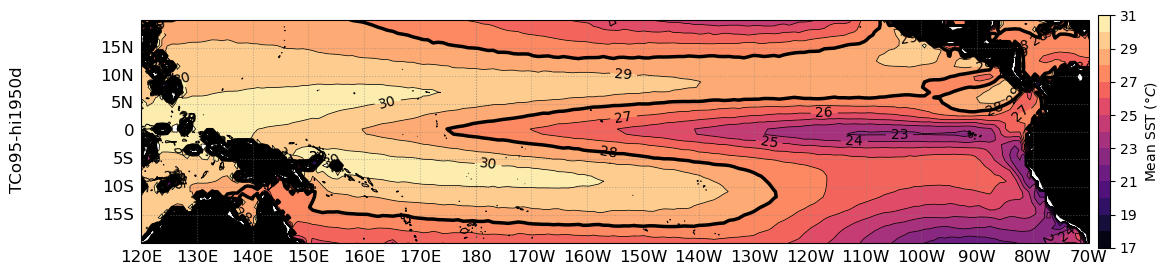

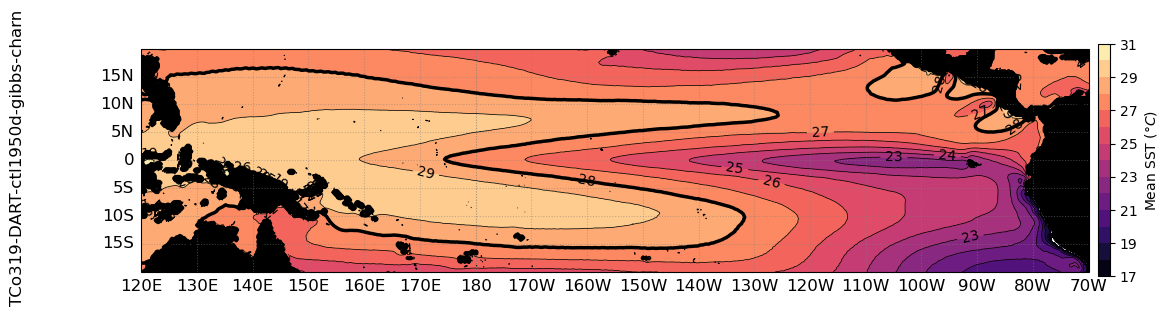

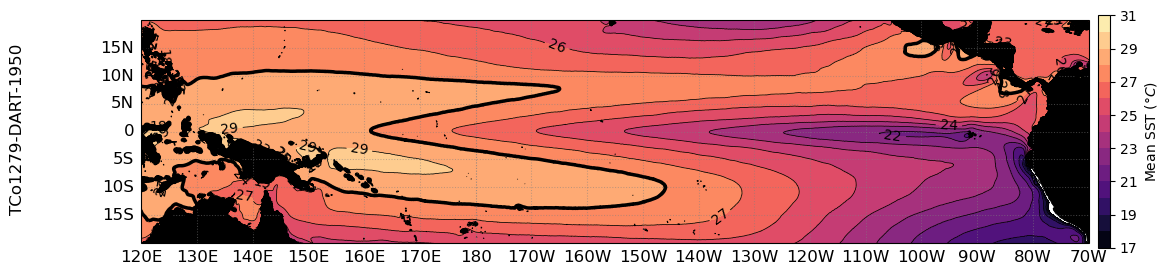

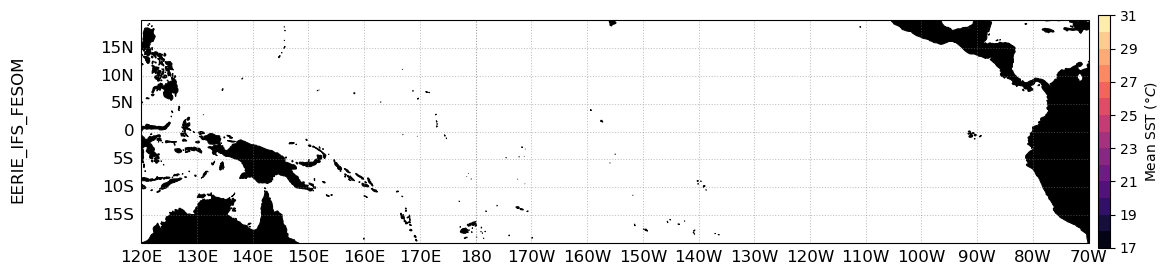

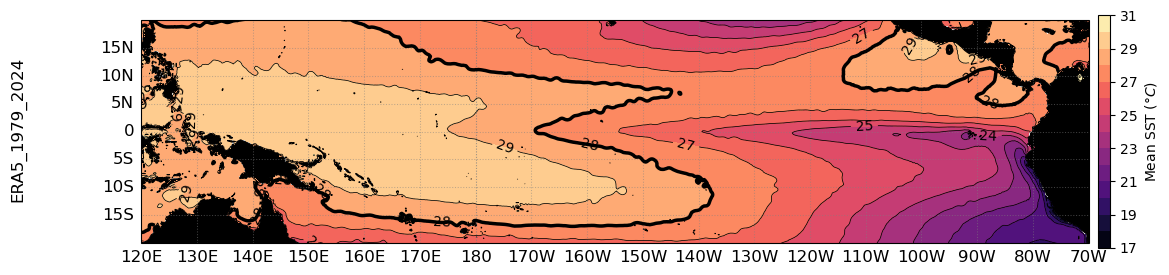

In [40]:
%%time

# Just Plot Means
cints_mean = np.arange(290,305,1) - 273

for ex in range(nexps):
    
    plotmean = mean_byexp[ex]
    
    fig,ax  = init_tp_map(1,1)

    plotvar = plotmean.squeeze() - 273
    pcm     = ax.contourf(plotvar.lon,plotvar.lat,plotvar,
                          transform=proj,levels=cints_mean,cmap='magma')
    cl      = ax.contour(plotvar.lon,plotvar.lat,plotvar,
                          transform=proj,levels=cints_mean,colors="k",linewidths=0.55)
    ax.clabel(cl)
    cl      = ax.contour(plotvar.lon,plotvar.lat,plotvar,
                          transform=proj,levels=[28],colors="k",linewidths=2.5)
    cb = fig.colorbar(pcm,ax=ax,pad=0.01,fraction=0.012)
    cb.set_label(r"Mean SST ($\degree C$)")
    fig.supylabel(expnames[ex])

    figname = "%sMean_SST_%s.png" % (figpath,expname)
    plt.savefig(figname,dpi=150,transparent=True)


### Plot Standard Deviation Only

CPU times: user 2min 28s, sys: 1.43 s, total: 2min 29s
Wall time: 2min 30s


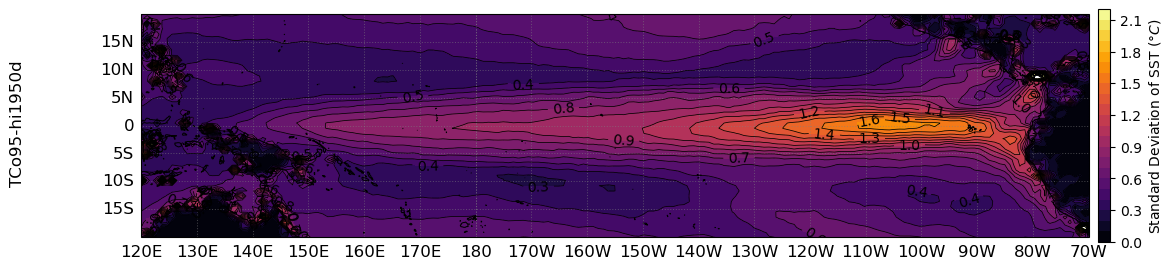

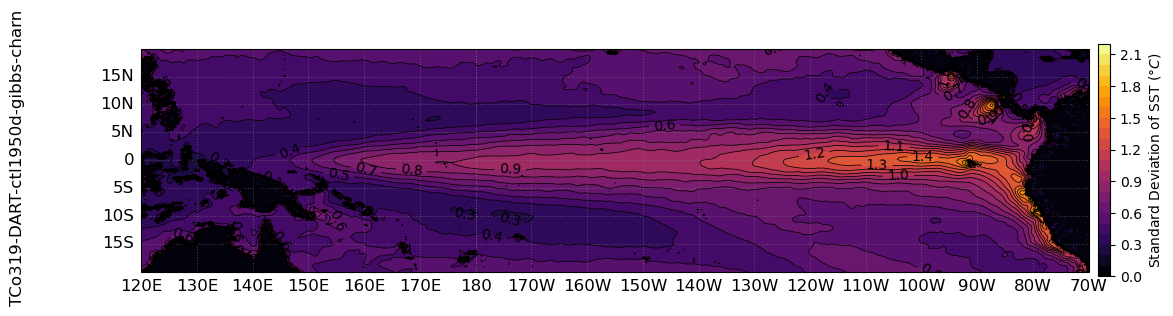

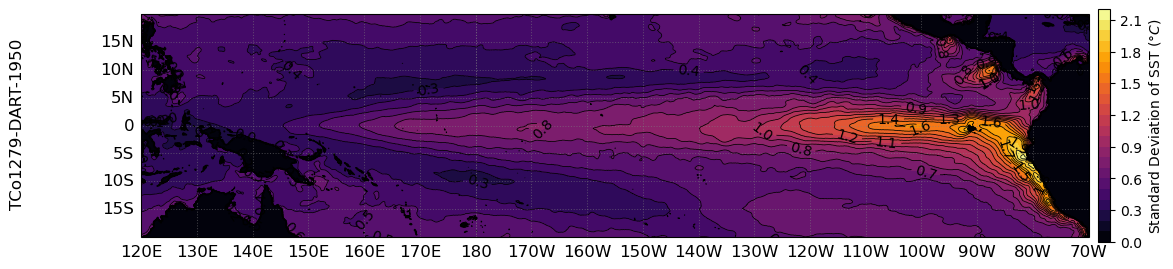

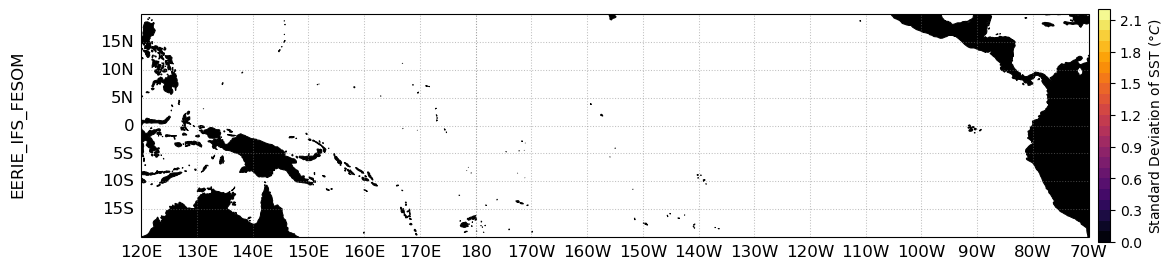

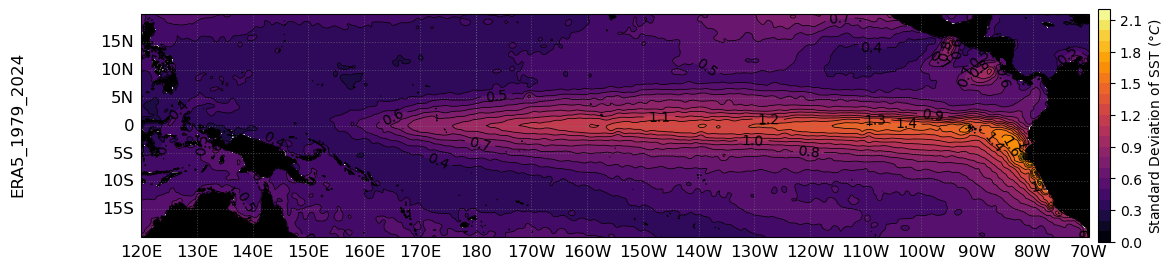

In [41]:
%%time 

# Plot Standard Deviations
cints_std  = np.arange(0,2.3,0.1)

for ex in range(nexps):
    plotstd  = std_byexp[ex]

    fig,ax  = init_tp_map(1,1)
    plotvar = plotstd.squeeze()
    pcm     = ax.contourf(plotvar.lon,plotvar.lat,plotvar,transform=proj,levels=cints_std,cmap='inferno')
    cl      = ax.contour(plotvar.lon,plotvar.lat,plotvar,
                          transform=proj,levels=cints_std,colors="k",linewidths=0.55)
    ax.clabel(cl)
    cb = fig.colorbar(pcm,ax=ax,pad=0.01,fraction=0.012)
    cb.set_label(r"Standard Deviation of SST ($\degree C$)")
    fig.supylabel(expnames[ex])

    figname = "%sStdev_SST_%s.png" % (figpath,expname)
    plt.savefig(figname,dpi=150,transparent=True)


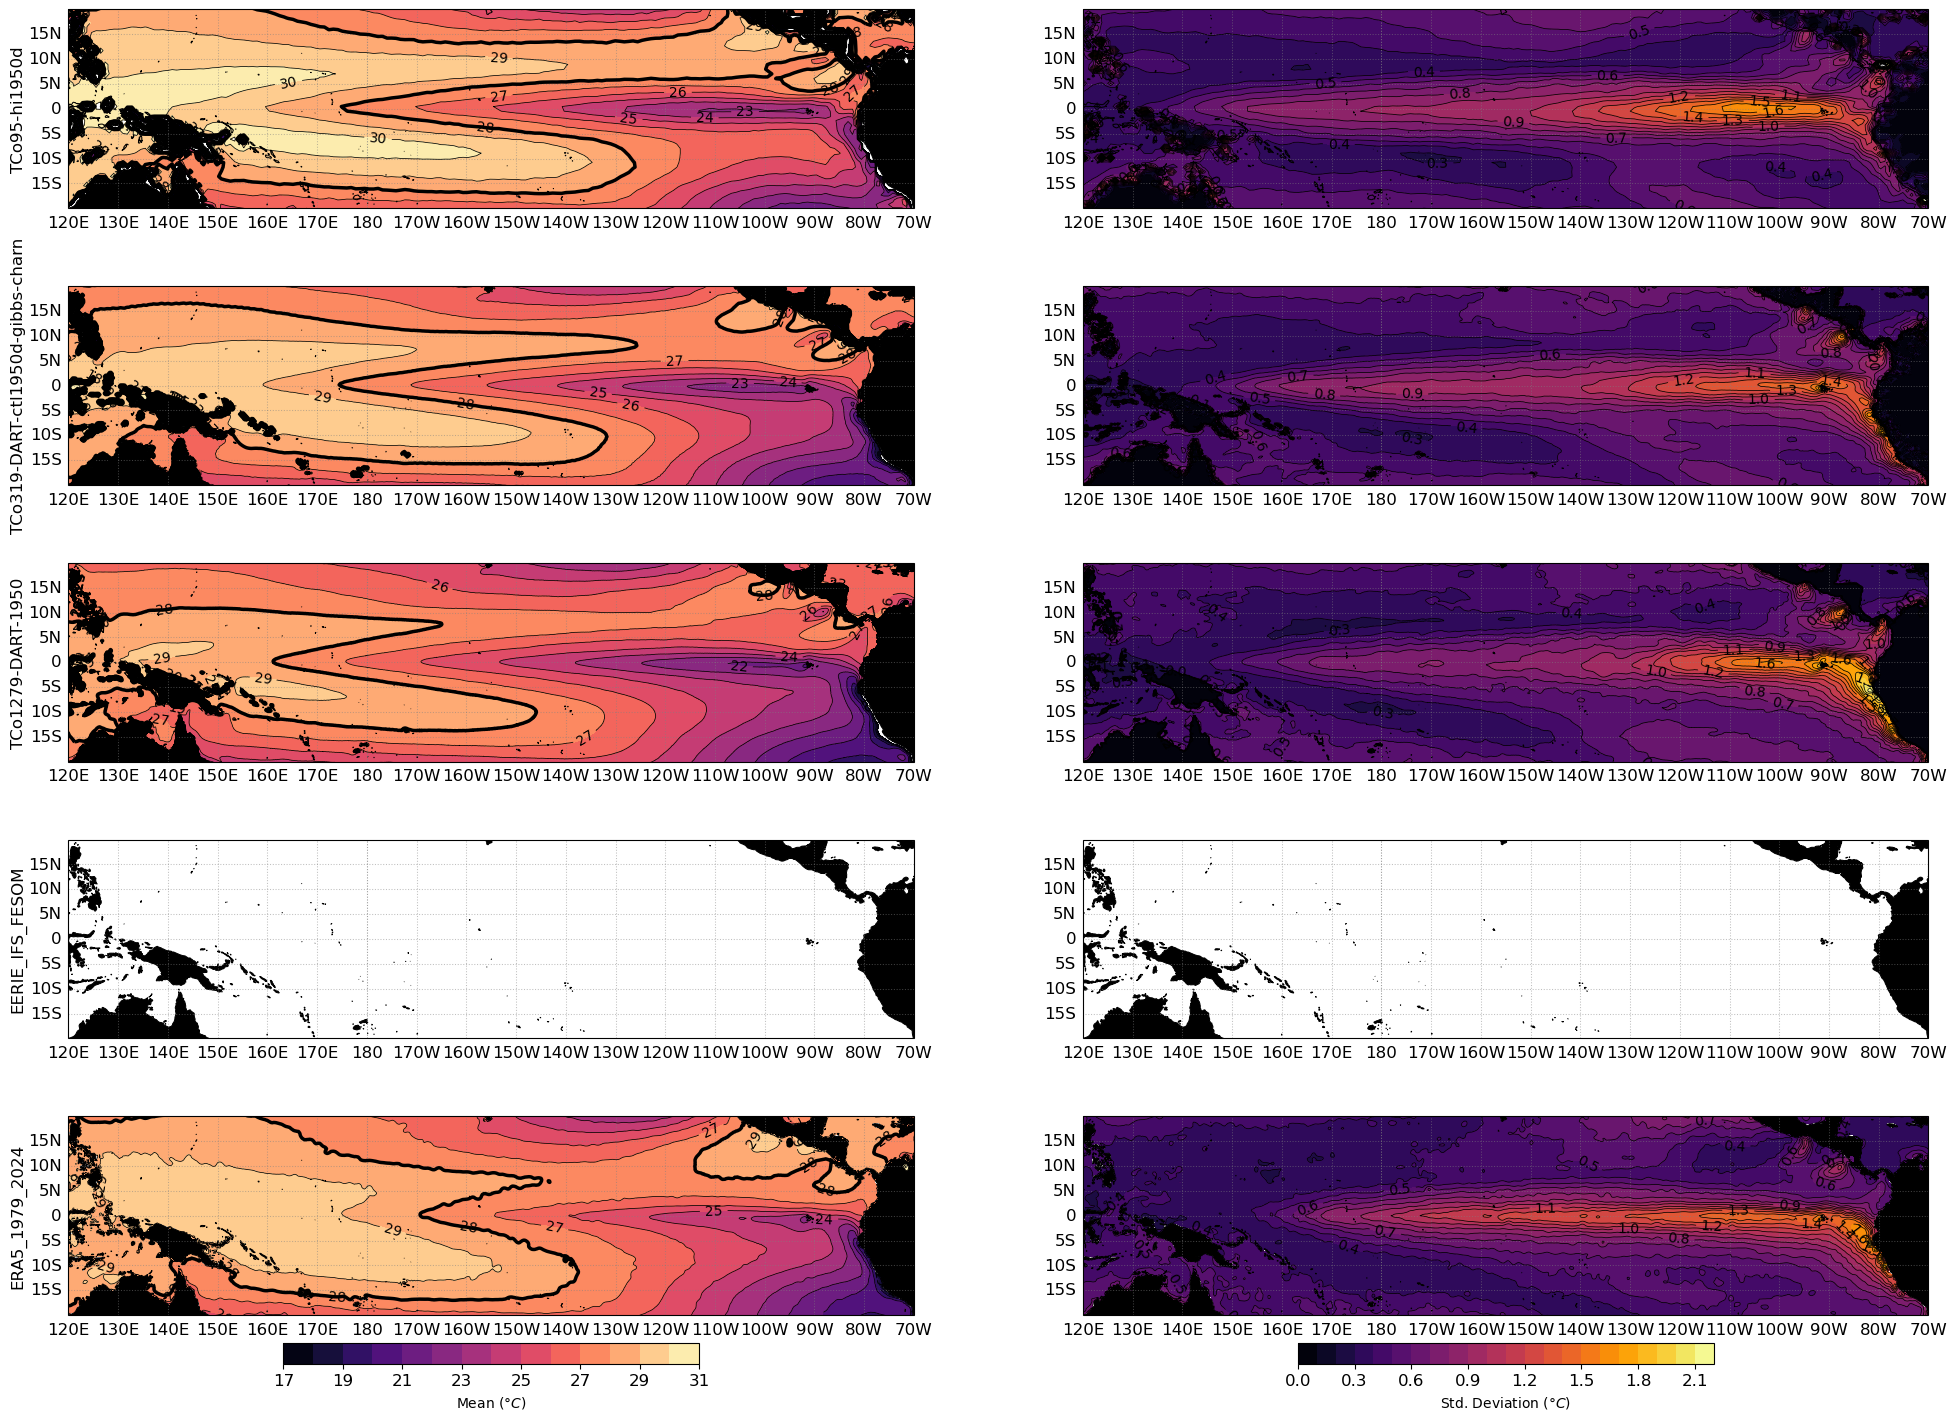

In [39]:
# Combined Version

nexp_final = 5 # 3 AWI-CM3 Resolutions + IFS-FESOM + Observations (ERA5 in this case)

# Comment this part out (mentioned in above cell blocks)
cints_std  = np.arange(0,2.3,0.1)
cints_mean = np.arange(290,305,1) - 273
proj       = ccrs.PlateCarree()

fig,axs    = init_tp_map(5,2,figsize=(24,18))

for mm in range(2):
    if mm == 0:
        metricname= r"Mean ($\degree C$)"
        cmap  = "magma"
        cints = cints_mean
    else:
        metricname=r"Std. Deviation ($\degree C$)"
        cmap = "inferno"
        cints = cints_std
    
    for ex in range(nexp_final):
        
        # Selecting Plotting variable and set up axis ===========
        ax      = axs[ex,mm]
        expname = expnames[ex]
        if mm == 0:
            add_ylabel(expname,ax=ax,x=-0.05)
            plotvar  = mean_byexp[ex].squeeze() - 273 # Convert from Kelvin
        else:
            plotvar  = std_byexp[ex].squeeze()

        # Do Plotting ==============
        pcm     = ax.contourf(plotvar.lon,plotvar.lat,plotvar,transform=proj,levels=cints,cmap=cmap)
        cl      = ax.contour(plotvar.lon,plotvar.lat,plotvar,
                              transform=proj,levels=cints,colors="k",linewidths=0.55)
        ax.clabel(cl)
        if mm == 0: # Plot Convection Threshold
            cl      = ax.contour(plotvar.lon,plotvar.lat,plotvar,
                          transform=proj,levels=[28],colors="k",linewidths=2.5)

        # Colorbar ==============
        if ex == (nexp_final-1):
            cb = hcbar(pcm,ax=axs[:,mm].flatten(),pad=0.02,fraction=0.015)
            cb.set_label(metricname)
            
            
        
        


# ENSO Characteristics

To run this script:

1. Indicate path to directory containing the ENSO indices with the variable `ensopath`, and optionally declare the name using `ensoid_name`. To simplify things, I've provided pre-calculated indices at this google drive link: https://drive.google.com/drive/folders/12uwQzob-3b4HYPuug61czeSdxmw38Fhj?usp=drive_link

2. Modify `expnames` to indicate which experiments/model runs you want to visualize and the `expcolors` to set the line color.

Note: This cell can be skipped/replaced, as long as the output is a list of ENSO indices (`enso_indices`) contained in `xr.DataArrays` with the dimension `time` and corresponding `expnames` and `expcolors`.

In [33]:
# 2026.07.28: Updated/Reduced Set for Paper

# Set paths to ENSO Indices and other Files
# Note: may need to modify [enso_nc] if your naming convention is different...
ensopath          = "/home/niu4/gliu8/projects/scrap/nino34/" # (!!) Set Path to ENSO Indices
ensoid_name       = "nino34" # Name of ENSO Index
standardize       = False    # Set to True to return standardized ENSO Indices

# Load the Files
nexp         = len(expnames)
enso_indices = []
for ex in range(nexp):
    
    expname           = expnames[ex]    
    try:
        enso_nc           = "%s%s_%s.nc" % (ensopath,expname,ensoid_name) # ex: <path_to_file>/TCo1279-DART-2060_nino34.nc
        print("Loading the following file: %s" % enso_nc)
        
        ds = xr.open_dataset(enso_nc).load()
        
        if standardize is False: # The provided indices were standardized by the value 'std'
            ds = ds.sst * ds['std']
        else:
            ds = ds.sst
    except:
        print("ENSO Indices not found for %s" % expname)
        ds = xr.ones_like(ds) * np.nan

    enso_indices.append(ds)
        

Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo95-hi1950d_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo319-DART-ctl1950d-gibbs-charn_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/TCo1279-DART-1950_nino34.nc
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/EERIE_IFS_FESOM_nino34.nc
ENSO Indices not found for EERIE_IFS_FESOM
Loading the following file: /home/niu4/gliu8/projects/scrap/nino34/ERA5_1979_2024_nino34.nc


# Monthly Standard Deviation

Similar to Moon et al. 2025 Figure 17 Panels f-h

1. Compute standard deviation for anomalies of each month.
2. Visualize output as bar plot.

This plot was modified to match the style in Stuecker et al. 2025, Supplementary Figure 12a.

In [34]:
%%time
# Calculate Monthly Standard Deviation
monthly_stdev = [ds.groupby('time.month').std('time') for ds in enso_indices]

CPU times: user 887 ms, sys: 144 ms, total: 1.03 s
Wall time: 5.87 s


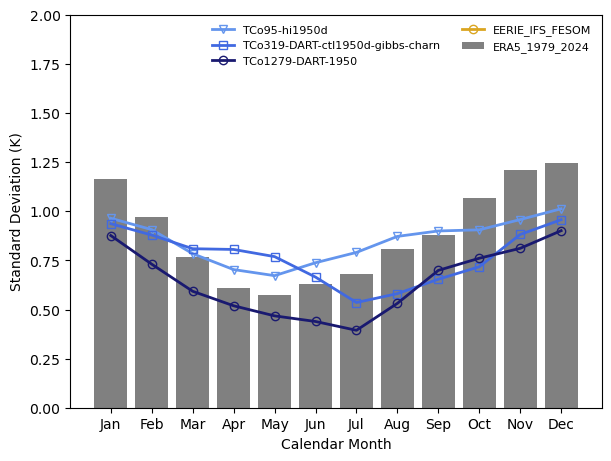

In [35]:
# Make Combined Plot of Monthly Stdev., Akin to Supplemental Figure 12 A.

# Plotting Options
x            = np.arange(12)  # the label locations
width        = 0.25           # the width of the bars
refex        = expnames.index("ERA5_1979_2024") # Reference Variable to plot as bars (usually observations  or reanalysis)
mons3        = [cal.month_name[i][:3] for i in np.arange(1,13,1)] # Months for Labeling
label_bars   = False
ymax         = 2 # Maximum of y axis

# Other Edits

# Initialize Figure
fig,ax       = plt.subplots(1,1,layout='constrained',figsize=(6,4.5))

for ex in range(nexp):

    plotvar  = monthly_stdev[ex].data
    label    = expnames[ex]
    color_in = expcolors[ex]


    if "TCo95" in label:
        mks = "v"
    elif "TCo319" in label:
        mks = "s"
    elif "TCo1279" in label:
        mks = "o"
    elif "TCo2559" in label:
        mks = "^"
    else:
        mks = "o"
    
    # Plot Bars if Reference Variable
    if ex == refex:
        rects   = ax.bar(mons3, plotvar, label=label,
                            color=color_in)
    else:
        ax.plot(mons3,plotvar, label=label,
                            color=color_in,linewidth=2,fillstyle="none",marker=mks)

ax.set_xticks(x,mons3)
ax.set_ylim([0,ymax])
ax.set_ylabel("Standard Deviation (K)")
ax.set_xlabel("Calendar Month")
ax.legend(fontsize=8,ncol=2,frameon=False)


figname = figpath+"Monvar_Stuecker_etal.png"
plt.savefig(figname,dpi=150,bbox_inches='tight',transparent=True)

## Power Spectra

Based on the notebook `RO_practical_with_CRO_framework.ipynb`
https://github.com/senclimate/RO_practical/blob/main/CRO_test/RO_practial_with_CRO_framework.ipynb
by Sen Zhao and Soong-Ki Kim

Uses the "pmtm" function from Sen Zhao's XRO utilities (XRO/stats.py)
https://github.com/senclimate/XRO

This plot was modified to match the style in Stuecker et al. 2025, Supplementary Figure 12b.

Note: Data length for some of the simulations is quite short (TCo1279 and TCo2559 simulations)

In [37]:
# For Each Index, Compute the Power Spectrum using the Multi-Taper Method
psd_byexp     = []
psd_sig_byexp = []
for ex in range(nexp):
    index_in                 = enso_indices[ex]
    try:
        psd, psd_sig, psd_ci_obs = pmtm( index_in, dim='time', dt=1/12, nw=5)
    except:
        print("Inserting NaNs for missing experiment %s" % expname)
        psd = xr.ones_like(psd) * np.nan
        psd_sig = xr.ones_like(psd_sig) * np.nan
    psd_byexp.append(psd)
    psd_sig_byexp.append(psd_sig)

Inserting NaNs for missing experiment ERA5_1979_2024


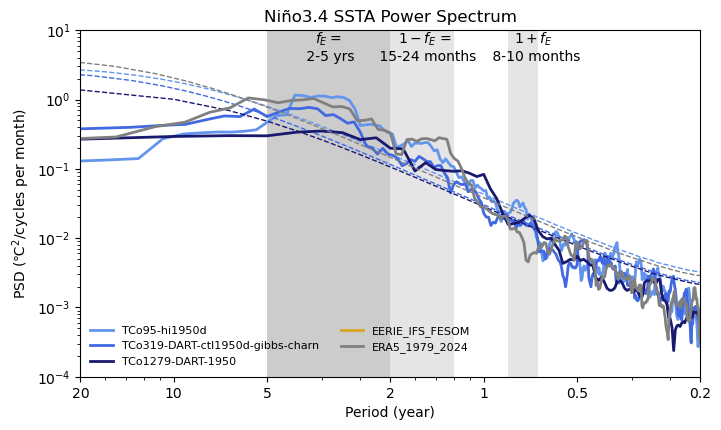

In [38]:

lw = 2 # Indicate Line Width for the spectra

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

for ex in range(nexp):

    psd = psd_byexp[ex]
    psd_sig = psd_sig_byexp[ex]
    color_in = expcolors[ex]
    lab = expnames[ex]
    
    ax.loglog(psd.freq, psd, lw=lw, color=color_in, label=lab)
    ax.plot(psd_sig.freq, psd_sig, lw=1., color=color_in, linestyle='--', label='')

# Initialize Plot
per = [50,20,10,5,2,1,0.5,0.2]
xt = 1.0/np.array(per)
ax.set_xticks(xt)
ax.set_xticklabels(map(str, per))
ax.set_ylabel('PSD (℃$^2$/cycles per month)')
ax.set_xlabel('Period (year)')
ax.set_xlim([1/20, 5])
ax.set_ylim([1e-4, 10])

ax.legend(ncol=2,frameon=False,fontsize=8)

y_min, y_max = ax.get_ylim()
#Mfreq_enso = np.array([1/2.5, 1/5.5])
Mfreq_enso = np.array([1/2, 1/5])
Mfreq_fplus = 1 + Mfreq_enso
Mfreq_fmins = 1 - Mfreq_enso

ax.fill_between(Mfreq_enso, y_min, y_max, fc='gray', alpha=0.4)
ax.fill_between(Mfreq_fplus, y_min, y_max, fc='gray',  alpha=0.2)
ax.fill_between(Mfreq_fmins, y_min, y_max, fc='gray', alpha=0.2)

#ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2.5-5.5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_enso)*0.9, y_max, '$f_{E}=$\n 2-5 yrs', ha='center', va='top')
ax.text(np.mean(Mfreq_fplus)+0.1, y_max, '$1+f_{E}$\n 8-10 months', ha='center', va='top')
ax.text(np.mean(Mfreq_fmins), y_max, '$1-f_{E}$ = \n 15-24 months', ha='center', va='top')
ax.set_title('Niño3.4 SSTA Power Spectrum')


figname = figpath+"Spectra_Stuecker_etal.png"
plt.savefig(figname,dpi=150,bbox_inches='tight',transparent=True)